In [1]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # 词汇表大小
    "context_length": 256, # 缩小的上下文长度 (原来: 1024)
    "emb_dim": 768,        # 嵌入维度
    "n_heads": 12,         # 注意力头数量
    "n_layers": 12,        # 层数
    "drop_rate": 0.1,      # Dropout 率
    "qkv_bias": False      # 查询-键-值偏置
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # 推理时禁用 dropout

In [2]:
# 文本 → 词元 ID
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 使用 .unsequeeze(0) 添加 batch 维度
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 移除 batch 维度
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


最大化与目标词元对应的 softmax 概率值：更新模型权重，以便模型为我们想要生成的相应词元 ID 输出更高的值。**权重更新**是通过**反向传播**的过程完成的，这是训练深度神经网络的标准技术。反向传播需要一个损失函数，它会计算模型的预测输出（在这里是与目标词元 ID 对应的概率）与实际期望输出之间的差异。这个损失函数衡量的是模型的预测与目标值之间的偏差。

**交叉熵损失**用于衡量两个概率分布之间的差异——通常是标签（在这里是数据集中的词元）的真实分布和模型生成的预测分布（例如，由大语言模型生成的词元概率）之间的差异。它可以对离散的结果进行度量，类似于给定模型生成的词元概率时目标词元的负平均对数概率。因此，在实践中，“交叉熵”和“负平均对数概率”这两个术语是相关的，且经常可以互换使用。

**困惑度**通常与交叉熵损失一起用来评估模型在诸如语言建模等任务中的性能。它可以提供一种更易解释的方式来理解模型在预测序列中的下一个词元时的不确定性。它可以衡量模型预测的概率分布与数据集中实际词汇分布的匹配程度。与损失类似，较低的困惑度表明模型的预测更接近实际分布。

In [3]:
# 输入示例
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

# 期望输出
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

# 将输入提供给模型，为包含 3 个词元的两个输入示例计算 logits 向量
# 未开始训练，屏蔽模型参数的梯度跟踪
with torch.no_grad():
    logits = model(inputs)

# 用 softmax 函数将这些 logits 转换为概率分数
probas = torch.softmax(logits, dim=-1) # 词汇表中每个词元的概率
# 输出概率分数（probas）张量的最终张量维度
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


In [4]:
# 将 argmax 函数应用于概率分数，获取所有预测的词元ID，在每个行向量中找到概率值最高的索引位置，从而获得相应的词元 ID
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [5]:
# 将词元 ID 转换回文本
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [6]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [7]:
from previous_chapters import create_dataloader_v1

# 训练集/验证集比例
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [8]:
# 计算训练集和验证集损失，以量化评估模型生成的文本的性能
# 计算单个批次的损失
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

# 计算由给定数据加载器采样的所有批次的损失
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        # 如果没有指定遍历多少个批次（num_batches），那么就遍历所有批次
        num_batches = len(data_loader)
    else:
        # 如果 num_batches 超过数据加载器中的批次数，那么就需要减少批次数，以匹配数据加载器中的总批次数
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # 每个批次的损失的总和
            total_loss += loss.item()
        else:
            break
    # 对所有批次的损失求平均值
    return total_loss / num_batches

In [9]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # 没有开始训练，所以不使用梯度追踪
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.987583266364204
Validation loss: 10.98110580444336


<div text-align:="center">
    <a href="../../pictures/training.png">
</div>

<div align="center">
    <img src="../pictures/training.png" width=70%>
</div>

In [10]:
# 预训练模型主函数
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表以跟踪损失和所见的词元
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # 主训练循环
    for epoch in range(num_epochs):
        model.train()  # 将模型置为训练模式

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 重置上一个批次迭代中的损失梯度
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 计算损失梯度
            optimizer.step() # 使用损失梯度更新模型权重
            tokens_seen += input_batch.numel()
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每轮之后打印一个文本样本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # 在评估阶段禁用 dropout，以产出稳定且可复现的结果
    model.eval()
    # 评估阶段也会禁用梯度跟踪，因为这是不需要的，而且这样可以减少计算开销
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 紧凑的打印格式
    model.train()

AdamW 是 Adam 的一个变体，它改进了权重衰减方法，旨在通过对较大的权重进行惩罚来最小化模型复杂性并防止过拟合。这种调整使得 AdamW 能够实现更有效的正则化和更好的泛化能力。

In [11]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                         

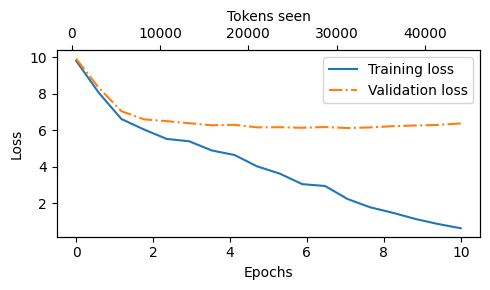

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 绘制训练损失和验证损失随训练轮数的变化曲线
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # x 轴上仅显示整数标签

    # 创建第二个 x 轴，用于表示看到的标记数。
    ax2 = ax1.twiny()  # 创建第二个与 y 轴相同的 x 轴
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 对齐刻度线的隐藏图表
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # 调整布局以腾出空间
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

通过文本生成策略（也称为“解码策略”)，生成更具原创性的文本，通过两种技术（温度缩放和 Top-k 采样）来改进 generate_and_print_sample 函数中的 generate_text_simple 函数来实现。

In [13]:
# 将模型从 GPU 转移到 CPU
inference_device = torch.device("cpu")
model.to(inference_device)

# 将模型置于评估模式，以关闭如 dropout 之类的随机组件
model.eval()

# 使用大语言模型逐个生成词元
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




温度缩放是一种在下一个词元生成任务中添加概率选择过程的技术。为了生成更多样化的文本，可以用一个从概率分布中采样的函数来取代 argmax。温度缩放指的是将 logits 除以一个大于 0 的数。温度大于 1 会导致词元概率更加均匀分布，而小于 1 的温度将导致更加自信（更尖锐或更陡峭）的分布。

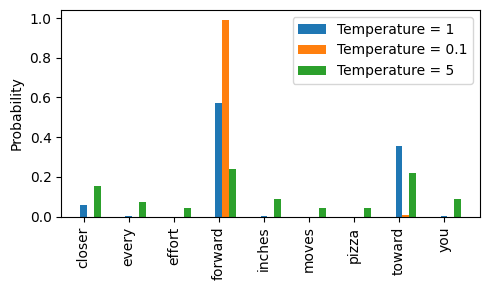

In [14]:
# 温度缩放

# 定义词汇表：将单词映射为数字索引
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

# 反向词汇表：用于根据索引查找单词
inverse_vocab = {v: k for k, v in vocab.items()}

# 模拟模型输出的原始分值 (Logits)
# 分值越高，代表该单词被选中的可能性越大
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

# 标准 Softmax：将 Logits 转换为概率分布（总和为 1）
probas = torch.softmax(next_token_logits, dim=0)
# 贪婪搜索：直接选取概率最大的单词索引
next_token_id = torch.argmax(probas).item()

# 随机采样：根据概率分布随机抽取一个单词
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()

# 辅助函数：模拟 1000 次采样并统计每个词出现的频次
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

# 带温度系数的 Softmax 计算公式：Softmax(Logits / T)
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# 设置不同的温度值进行对比
# T=1: 原始分布；T=0.1: 趋于确定（集中于高分词）；T=5: 趋于随机（平滑分布）
temperatures = [1, 0.1, 5]

# 计算不同温度下的概率分布
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# 可视化绘图
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    # 为每种温度绘制一组柱状图
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability') # 纵轴：概率
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90) # 横轴：单词名称
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

首先定义了单词与 Logits（原始分值）的映射，随后通过核心函数将 Logits 除以温度系数 $T$，再利用 Softmax 将其转化为概率分布；通过对比发现，低温度会拉大分值差距使输出趋于确定（保守），高温度则会抹平差距使分布更均匀（随机），最后通过随机采样和可视化图表直观验证了温度调节对生成多样性的影响。

In [15]:
# Exercise 5.1
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
for i, probas in enumerate(scaled_probas):
    print("\n\nTemperature:", temperatures[i])
    print_sampled_tokens(probas)



Temperature: 1
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


Temperature: 0.1
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


Temperature: 5
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


In [16]:
temp5_idx = 2
pizza_idx = 6

scaled_probas[temp5_idx][pizza_idx]

tensor(0.0430)

温度缩放的一个缺点是，它有时会导致语法不正确或完全无意义的输出；通过与概率采样和温度缩放相结合，Top-k 采样可以改善文本生成结果, 其核心思想是：**在进行随机采样前，只保留概率最高的前 $k$ 个候选词，将其余词的概率强行降为 0**。在 Top-k 采样中，可以将采样的词元限制在前 k 个最可能的词元上，并通过掩码概率分数的方式来排除其他词元。Top-k 方法用负无穷值（-inf）替换所有未选择的 logits，因此在计算 softmax 值时，非前 k 词元的概率分数为 0，剩余的概率总和为 1。

In [17]:
# Top-k 采样
top_k = 3
# 筛选前 k 名
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [18]:
# 掩码处理
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [19]:
# 重新计算概率（归一化）
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [20]:
# 更新文本生成函数（加入温度放缩和 TOP-k 采样）
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # 循环生成新 Token：获取 Logits，并只关注最后一个时间步
    for _ in range(max_new_tokens):
        # 裁剪上下文，确保长度不超过模型允许的最大范围
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        # 取最后一个时间步的输出 (Batch, Vocab_size)
        logits = logits[:, -1, :]

        # 新增：使用 Top-k 采样过滤 Logits
        if top_k is not None:
            # 仅保留前 k 个最大值
            top_logits, _ = torch.topk(logits, top_k)
            # 获取第 k 名的分值作为阈值
            min_val = top_logits[:, -1]
            # 将小于该阈值的分值替换为负无穷 (-inf)
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 新增：应用温度缩放
        if temperature > 0.0:
            logits = logits / temperature

            # 提示（非原书内容）：为了数值稳定性（如在 MPS 设备上），在 Softmax 前减去每行的最大值
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # 应用 Softmax 将 Logits 转换为概率分布
            probs = torch.softmax(logits, dim=-1)  # (batch_size, vocab_size)

            # 从分布中随机采样下一个 Token 索引
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # 否则（温度为0时）：执行贪婪搜索，直接取概率最大的索引
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        # 如果遇到了指定的结束符 (EOS)，则提前停止生成
        if idx_next == eos_id:
            break

        # 将生成的索引拼接当前序列，继续迭代
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [21]:
torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


In [22]:
# Exercise 5.2

## topk为 1，temperature 为 1.4
top_k = 1
top_logits, top_pos = torch.topk(next_token_logits, top_k)
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
topk_probas = torch.softmax(new_logits, dim=0)

torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=1.4
)
print("Output text（topk为 1，temperature 为 1.4）:\n", token_ids_to_text(token_ids, tokenizer))

## topk为 3，temperature 为 0
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
topk_probas = torch.softmax(new_logits, dim=0)

torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=0
)
print("Output text（topk为 3，temperature 为 0）:\n", token_ids_to_text(token_ids, tokenizer))

## topk为 3，temperature 为 3
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
topk_probas = torch.softmax(new_logits, dim=0)

torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=3
)
print("Output text（topk为 3，temperature 为 3）:\n", token_ids_to_text(token_ids, tokenizer))

## topk为 1，temperature 为 1.4
top_k = 5
top_logits, top_pos = torch.topk(next_token_logits, top_k)
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
topk_probas = torch.softmax(new_logits, dim=0)

torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=1.4
)
print("Output text（topk为 5，temperature 为 1.4）:\n", token_ids_to_text(token_ids, tokenizer))

Output text（topk为 1，temperature 为 1.4）:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head
Output text（topk为 3，temperature 为 0）:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted
Output text（topk为 3，temperature 为 3）:
 Every effort moves youlit," Gis surprise you can--because he had an object for enough
Output text（topk为 5，temperature 为 1.4）:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


温度和最高温度设置都需要根据各个 LLM 以及具体场景进行调整（需要反复尝试不同参数直到产生理想的输出）。
   
较低的 top-k 值和 temperaure 会导致随机结果减少，这在创建教育内容、技术写作或问答、数据分析、代码生成等方面是理想的。
较高的 top-k 值和 temperature 会产生更多样化和随机的输出，这更适合头脑风暴、创意写作等任务。

In [23]:
# Exercise 5.3
## generate_text_simple
start_context = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


## generate
### topk为 1，temperature 为 0
top_k = 1
top_logits, top_pos = torch.topk(next_token_logits, top_k)
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
topk_probas = torch.softmax(new_logits, dim=0)

torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=0
)
print("Output text（topk为 1，temperature 为 0）:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"


Output text（topk为 1，temperature 为 0）:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted


In [24]:
# 权重保存
torch.save(model.state_dict(), "model.pth")

In [25]:
# 权重加载
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cuda


In [26]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [27]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [28]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])
[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [29]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [30]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [31]:
# 从 OpenAI 加载预训练权重
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device);

In [32]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


In [33]:
# Exercise 5.5

## gpt2-small (124M)
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

load_weights_into_gpt(gpt, params)
gpt.to(device)

torch.manual_seed(123)
train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)

print("gpt2-small (124M)")
print("Training loss:", train_loss)
print("Validation loss:", val_loss)


## gpt2-large (774M)
settings, params = download_and_load_gpt2(model_size="774M", models_dir="gpt2")

model_name = "gpt2-large (774M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

load_weights_into_gpt(gpt, params)
gpt.to(device)

torch.manual_seed(123)
train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)

print("gpt2-large (774M):\n")
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

gpt2-small (124M)
Training loss: 3.754763126373291
Validation loss: 3.5596330165863037


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 86.2kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.94MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 43.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 3.10G/3.10G [03:27<00:00, 14.9MiB/s]
model.ckpt.index: 100%|██████████| 15.5k/15.5k [00:00<00:00, 24.2MiB/s]
model.ckpt.meta: 100%|██████████| 1.38M/1.38M [00:00<00:00, 3.56MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.58MiB/s]


gpt2-large (774M):

Training loss: 3.382859230041504
Validation loss: 3.210003137588501


In [37]:
# Exercise 5.6
## gpt2-large (774M)
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device) # 确保模型在 GPU 上

# 将输入的 token_ids 转移到模型所在的 device
input_ids = text_to_token_ids("Every effort moves you", tokenizer).to(device)

token_ids = generate(
    model=gpt,
    idx=input_ids,
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the final decision is concerned," the lawyer wrote, "which means there's a very small delay before you lose


第5章主要讲解了如何在无标签数据上对大语言模型进行预训练。

**1. 文本生成与模型质量评估**
本章首先回顾了基于大语言模型架构的文本生成过程，并介绍了如何通过交叉熵损失和困惑度（Perplexity）来量化评估生成文本的质量。由于未经过训练的模型输出的是随机概率，其生成的文本往往是不连贯的。为了量化这种差距，我们通过计算模型预测词元的概率与实际目标词元之间的负平均对数概率（交叉熵损失）来衡量预测偏差。这个损失值不仅能反映模型当前的不确定性（困惑度），也是后续通过反向传播更新模型权重、优化生成质量的核心依据。

**2. 大语言模型的预训练循环**
预训练大语言模型的核心是实现一个标准的PyTorch深度神经网络训练工作流程。该过程包括在多个训练轮次中遍历数据批次，计算每个批次的损失，通过反向传播计算损失梯度，最后使用AdamW优化器来更新模型权重以最小化训练集损失。其中，AdamW作为Adam优化器的变体，通过改进的权重衰减机制来惩罚较大的权重，有助于减少模型复杂性并防止过拟合。通过这一循环，模型生成的输出会逐渐从随机字符演变成语法正确的连贯文本。

**3. 控制文本生成随机性的解码策略**
为了避免模型对训练数据的逐字记忆，并增加生成文本的多样性与独创性，本章引入了温度缩放（Temperature Scaling）和Top-k采样两种文本解码策略。传统的“贪婪解码”每次只挑选概率最高的词元，而温度缩放通过在计算Softmax前将logits除以一个温度参数，来平滑或锐化概率分布，从而引入合理的随机性。Top-k采样进一步将候选范围限制在概率最高的前k个词元中，利用负无穷掩码排除极低概率的词元。将这两种技术结合到文本生成函数中，既能保证文本的合理性，又能激发出更丰富的生成路径。

**4. 模型权重的保存与加载**
鉴于大语言模型的训练需要消耗大量时间和计算资源，掌握如何保存和加载模型参数（权重）对于后续推断和持续训练至关重要。本章演示了利用PyTorch的`torch.save`函数将模型的`state_dict`（包含网络层与参数映射的字典）以及优化器的历史状态数据保存为本地文件（如.pth格式）。通过`torch.load`及相关的加载方法，开发者可以随时恢复训练进度，或者在切换到评估模式（`model.eval()`，以禁用dropout层）后直接将模型投入推断使用。

**5. 从OpenAI加载预训练权重**
考虑到在大型数据语料库上从头训练一个大语言模型极其昂贵（可能耗费数十万美元的GPU成本），本章最后介绍了一种高效的替代方案：加载OpenAI开源的GPT-2预训练权重。尽管不同规模的GPT-2模型（从1.24亿到15.58亿参数）大小不同，但它们共享相同的核心Transformer架构，仅在嵌入层维度和模块重复次数上存在差异。通过编写特定的权重转换和映射函数，我们可以将OpenAI模型中的词元嵌入、多头注意力机制及前馈网络等权重逐一加载到自定义的PyTorch模型实例中，从而直接赋予模型强大的语言处理能力，为后续的微调任务打下坚实基础。